#**Resolução do Desafio Técnico Voxar**

Nome: Pedro Henrique Herculano da Silva (phhs)

###**Entendimento do problema:**
 Ao dar uma primeira olhada observo que o desafio consiste em classificar imagens de superfícies de vias em três classes: asphalt, belgian_blocks e offroad. Entretanto, percebo que o problema maior não estará centralizada na arquitetura do modelo utilizado mas sim no dataset.

Primeira coisa que observo é o grande desbalanceamento entre as classes, asphalt tem 655 imagens de treino, equanto belgian_blocks tem 94 e offroad 151. Isso significa que se eu não tiver cuidado, um modelo pode atingir uma acurácia razoável simplesmente apostando sempre em asphalt, com isso vamos logo de cara focar no f1-score.

Além do desbalanceamento, percebi problemas em qualidades visuais em algumas imagens. Algumas imagens foram capturadas a noite e em dia de chuva, o que acredito que vai ser um grande problema para arquiteturas.

###**Solução Baseline:**
Para estabelecer um ponto de partida, minha hipótese será que o uso de Transfer Learning e Class Weights é uma abordagem viável e eficiente para este conjunto de dados. Irei utilizar uma arquitetura pré treinada (Transfer Learning), como a resnet18, que foi feita exatamente para classificações de imagens. Irei modificar apenas a última camada, adequando ao problema principal (3 classes de pistas). O motivo da minha escolha é ser eficiente e prático. Treinar uma rede neural profunda "do zero" levaria inevitavelmente ao overfitting. Ao utilizar pesos pré-treinados, a rede já possui a capacidade de identificar bordas, formas e texturas genéricas.

Para ajudar no desafio do desbalanceamento dos dados, irei utilizar pesos para cada classe diretamente nas funções de custo. Dessa forma, um erro cometido ao classificar um belgian_blocks penaliza a rede matematicamente muito mais do que um erro cometido no asfalto, forçando o modelo a prestar atenção às classes minoritárias. E por fim, algumas técnicas de Data Augmentation para evitar overfitting e ao mesmo tempo ajudar no tratamento de imagens a noite.

Utilizei uma técnica chamada Early Stopping, que para o treinamento caso o modelo esteja há algumas épocas sem progressão, isso evita o overfitting e o uso excessivo de recursos computacionais.

##Configurações iniciais e imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

from pathlib import Path
import gc

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.metrics import f1_score

In [ ]:
!unzip -q dataset_processed.zip -d dataset
print("Dataset descompactado")

Dataset descompactado


In [ ]:
dataset_train = Path("dataset/dataset_processed/train")
dataset_test = Path("dataset/dataset_processed/test")

classes = sorted([d.name for d in dataset_train.iterdir() if d.is_dir()])
print(f"Classes encontradas: {classes}\n")

for cls in classes:
    n_train = len(list((dataset_train / cls).glob("*")))
    print(f"Classe {cls}: {n_train} imagens de treino")

Classes encontradas: ['asphalt', 'belgian_blocks', 'offroad']

Classe asphalt: 655 imagens de treino
Classe belgian_blocks: 94 imagens de treino
Classe offroad: 151 imagens de treino


##Preparação para treino da Resnet18

In [ ]:
# Transformações para o treino (com Augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # flip apenas na horizontal, nao faz sentido fazer flip na vertical para detecçao de pistas
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Bom para fotos noturnas/chuva
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Padrão ImageNet
])

# Transformações para o teste (apenas redimensionamento e normalização)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=dataset_train, transform=train_transforms)
test_dataset = ImageFolder(root=dataset_test, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Preparando os pesos

In [ ]:
counts = torch.tensor([655, 94, 151], dtype=torch.float)
# O peso é inversamente proporcional à frequência
weights = 1.0 / counts

weights = weights / weights.min() # Normalizando para o menor peso ser 1.0

print(f"Pesos das classes: {weights}")

Pesos das classes: tensor([1.0000, 6.9681, 4.3377])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Teste para saber se estou usando a GPU do colab
print(f"Rodando em: {device}")

Rodando em: cuda


##Treinando com a Resnet18

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

#Alterando a última camada (A Mágica do Transfer Learning)
# Na ResNet, a última camada se chama 'fc' (Fully Connected)
num_features = model.fc.in_features # Pega o número de neurônios que chegam nela (512 na ResNet-18)
model.fc = nn.Linear(num_features, 3) # Substitui por uma nova camada com 3 saídas

# Move o modelo para a GPU
model = model.to(device)

#  Configurando a Função de Perda (Loss) para o Desbalanceamento
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)# Otimizador

print("ResNet-18 pronta para o treino.")

num_epochs = 20
patience = 5 # numero maximo para early stop
count_epochs_earlystop = 0
best_f1 = 0.0 # Para guardar o melhor resultado

# Listas para guardar o histórico e plotar gráficos depois
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'test_f1': []}

print("Iniciando o treinamento da ResNet-18...")

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")
    print("-" * 15)

    model.train()
    running_train_loss = 0.0
    running_train_corrects = 0

    # Barra de progresso para o treino
    train_bar = tqdm(train_loader, desc="Treinando")

    for inputs, labels in train_bar:
        # Move os dados para a GPU
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zera os gradientes da rodada anterior
        outputs = model(inputs) # Forward (A rede tenta adivinhar o que é a imagem)
        loss = criterion(outputs, labels) # Calcula o erro (Loss) considerando os pesos das classes

        loss.backward()         # Backward (Calcula o quanto cada peso deve mudar)
        optimizer.step() # Otimizador dá um passo (Atualiza os pesos)

        _, preds = torch.max(outputs, 1)

        running_train_loss += loss.item() * inputs.size(0)
        running_train_corrects += torch.sum(preds == labels.data).item()
        train_bar.set_postfix(loss=loss.item()) # Mostra a loss atualizando na barra

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = running_train_corrects / len(train_loader.dataset) # Calcula Acurácia
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)


    # AVALIAÇÃO (TESTE)
    model.eval()
    running_test_loss = 0.0
    running_test_corrects = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            # Pega a classe com a maior probabilidade como sendo o chute da rede
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    epoch_test_acc = running_test_corrects / len(test_loader.dataset)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    # Calcula o F1-Score Macro (que ignora o desbalanceamento)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    history['test_f1'].append(epoch_f1)

    #print(f"Loss Treino: {epoch_train_loss:.4f} | Loss Teste: {epoch_test_loss:.4f} | F1-Score (Teste): {epoch_f1:.4f}")
    print(f"loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_test_loss:.4f} - val_accuracy: {epoch_test_acc:.4f} - (val_macro_f1: {epoch_f1:.4f})")

    # SALVAR O MELHOR MODELO

    if epoch_f1 > best_f1:
        print(f"Novo recorde de F1-Score ({epoch_f1:.4f})! Salvando os pesos do modelo...")
        best_f1 = epoch_f1
        count_epochs_earlystop = 0
        # Salva o "estado" do modelo (os pesos aprendidos)
        torch.save(model.state_dict(), 'melhor_resnet18.pth')
    else:
      count_epochs_earlystop += 1
      if count_epochs_earlystop >= patience:
        print(f"\nO modelo parou de melhorar há {patience} épocas. Treinamento encerrado para evitar overfitting.")
        break

print("\nTreinamento concluído!")

ResNet-18 pronta para o treino.
Iniciando o treinamento da ResNet-18...

Época 1/20
---------------


Treinando: 100%|██████████| 29/29 [00:19<00:00,  1.52it/s, loss=0.366]


loss: 0.4931 - accuracy: 0.8578 - val_loss: 4.2594 - val_accuracy: 0.0000 - (val_macro_f1: 0.4626)
Novo recorde de F1-Score (0.4626)! Salvando os pesos do modelo...

Época 2/20
---------------


Treinando: 100%|██████████| 29/29 [00:19<00:00,  1.52it/s, loss=0.228]


loss: 0.2857 - accuracy: 0.9078 - val_loss: 0.4601 - val_accuracy: 0.0000 - (val_macro_f1: 0.7172)
Novo recorde de F1-Score (0.7172)! Salvando os pesos do modelo...

Época 3/20
---------------


...

loss: 0.1475 - accuracy: 0.9500 - val_loss: 0.4625 - val_accuracy: 0.0000 - (val_macro_f1: 0.7910)

Época 8/20
---------------


Treinando: 100%|██████████| 29/29 [00:18<00:00,  1.54it/s, loss=0.31]


loss: 0.1552 - accuracy: 0.9444 - val_loss: 0.7587 - val_accuracy: 0.0000 - (val_macro_f1: 0.6670)

Época 9/20
---------------


Treinando: 100%|██████████| 29/29 [00:18<00:00,  1.58it/s, loss=0.0849]


loss: 0.2074 - accuracy: 0.9189 - val_loss: 0.4868 - val_accuracy: 0.0000 - (val_macro_f1: 0.7185)

O modelo parou de melhorar há 5 épocas. Treinamento encerrado para evitar overfitting.

Treinamento concluído!


##Analisando resultado da Resnet18

Carregando os pesos do melhor modelo


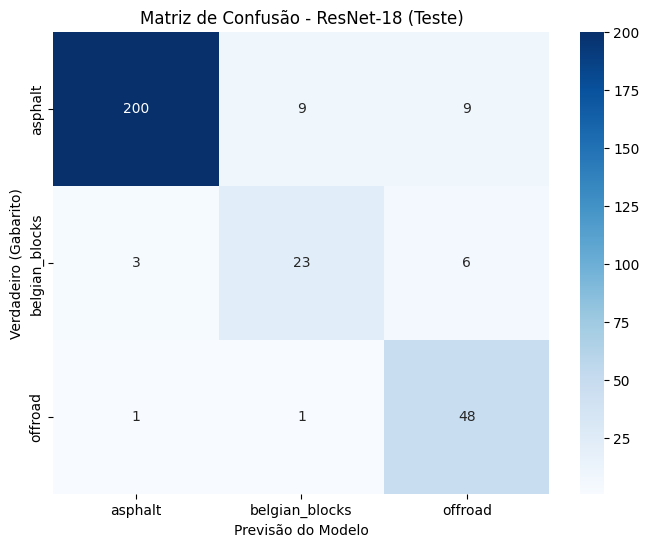


Relatório de Classificação Final:
                precision    recall  f1-score   support

       asphalt       0.98      0.92      0.95       218
belgian_blocks       0.70      0.72      0.71        32
       offroad       0.76      0.96      0.85        50

      accuracy                           0.90       300
     macro avg       0.81      0.87      0.84       300
  weighted avg       0.91      0.90      0.91       300



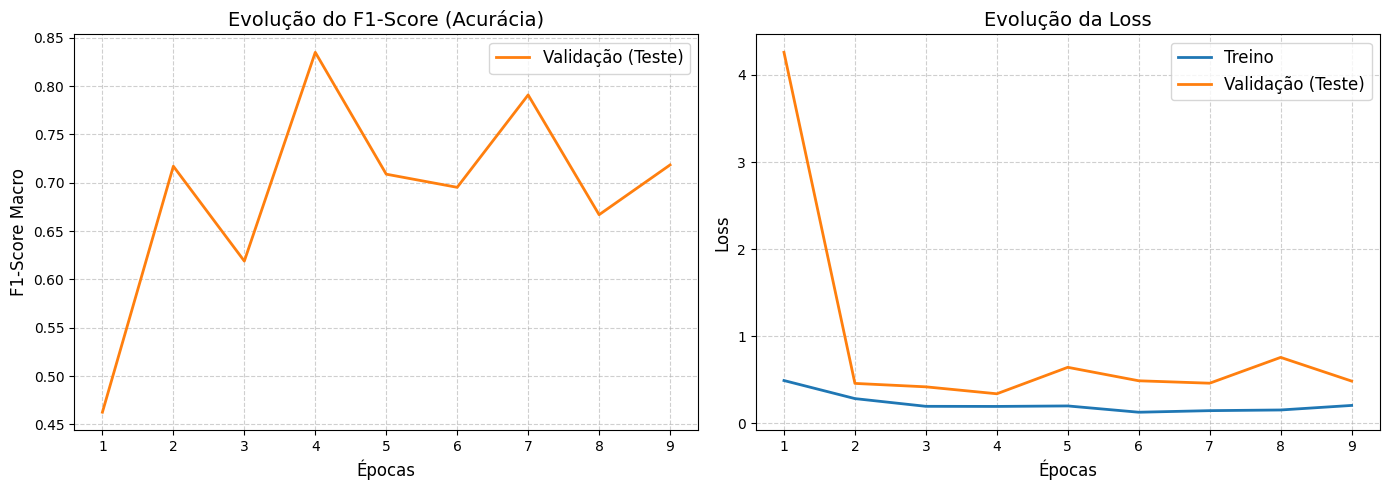

In [ ]:


print("Carregando os pesos do melhor modelo")
model.load_state_dict(torch.load('melhor_resnet18.pth'))
model.eval()

all_preds = []
all_labels = []

# Passa o dataset de teste inteiro pela rede uma última vez
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Pega os nomes das classes na ordem correta
class_names = test_dataset.classes


# Matriz de Confusão

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - ResNet-18 (Teste)')
plt.ylabel('Verdadeiro (Gabarito)')
plt.xlabel('Previsão do Modelo')
plt.show()

# Relatório de Métricas Detalhado
print("\nRelatório de Classificação Final:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Pega o número de épocas que realmente rodaram
epochs = range(1, len(history['train_loss']) + 1)

# Cria a figura com 2 gráficos lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Acurácia / F1-Score
# vamos plotar apenas a evolução da Validação/Teste.
ax1.plot(epochs, history['test_f1'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax1.set_title('Evolução do F1-Score (Acurácia)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('F1-Score Macro', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# Gráfico 2: Loss (Função de Custo)
# Aqui plotamos Treino vs Validação para ver se há Overfitting
ax2.plot(epochs, history['train_loss'], label='Treino', color='#1f77b4', linewidth=2)
ax2.plot(epochs, history['test_loss'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax2.set_title('Evolução da Loss', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

###Análise de desempenho por classe:


*   **Asphalt:** O modelo apresentou desempenho quase perfeito, com F1-Score de 0.95. A alta precisão (0.98) indica que a rede aprendeu os padrões visuais dominantes da pista pavimentada com grande confiabilidade.
*   **Belgian_blocks:** Esta classe configurou o principal gargalo da arquitetura base, registrando o menor F1-Score (0.71). A matriz de confusão revelou uma dificuldade da ResNet-18 em isolar a textura dos blocos de pedra, distribuindo seus erros ao confundir os blocos tanto com asfalto (padrões de rachaduras) quanto com terra (pistas sujas ou sem pavimentação uniforme).


*   **Offroad:** O desempenho foi excelente, atingindo um F1-Score de 0.85 e um impressionante recall de 0.96. Isso comprova que a técnica de Class Weights impediu o modelo de ignorar as vias de terra, permitindo que a rede identificasse 96% de todas as fotos off-road do teste.

##Imagens que o modelo errou

Total de imagens erradas no Teste: 29



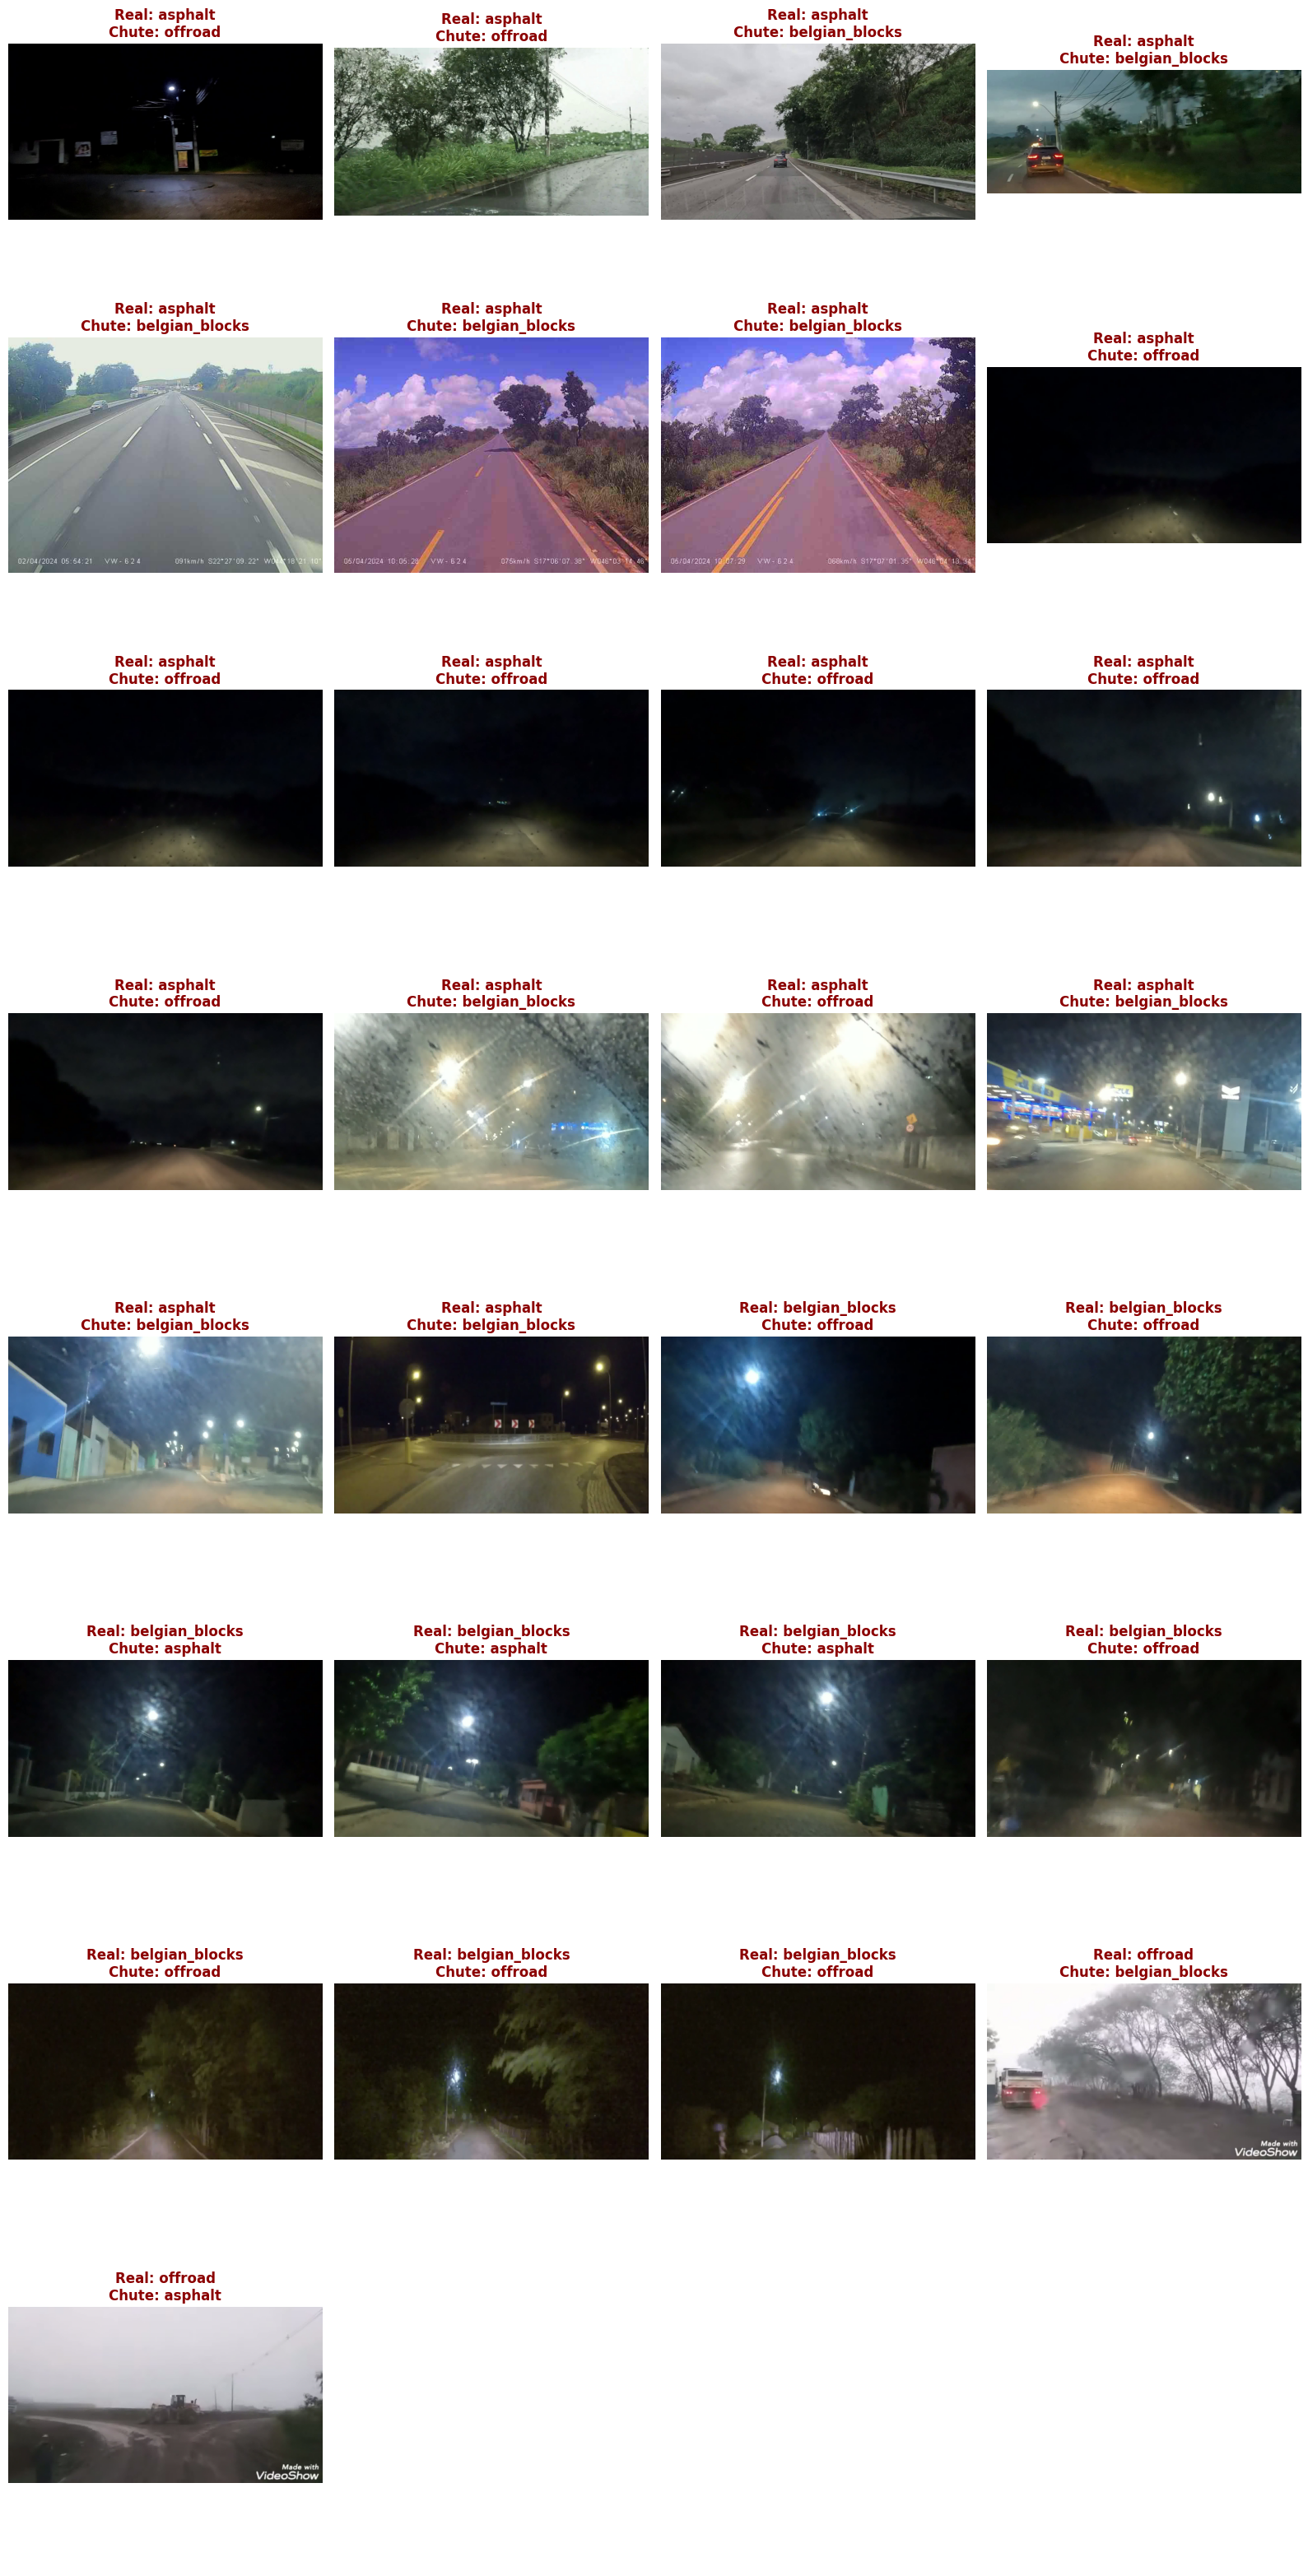

In [ ]:
from PIL import Image

# Encontra as posições (índices) exatas onde o modelo errou
erros_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]

print(f"Total de imagens erradas no Teste: {len(erros_indices)}\n")

# Configura a figura para mostrar até 8 erros (2 linhas e 4 colunas)
fig, axes = plt.subplots(8, 4, figsize=(16, 32))
axes = axes.flatten() # Achata a matriz de gráficos para facilitar o loop

for i, ax in enumerate(axes):
    if i < len(erros_indices):
        # Pega o índice do erro atual
        idx = erros_indices[i]

        # Pega o caminho do arquivo original direto do ImageFolder
        caminho_imagem = test_dataset.samples[idx][0]
        imagem = Image.open(caminho_imagem) # Abre a foto original (sem normalização)

        # Pega os nomes das classes para o título
        classe_real = class_names[all_labels[idx]]
        classe_prevista = class_names[all_preds[idx]]

        ax.imshow(imagem)
        ax.set_title(f"Real: {classe_real}\nChute: {classe_prevista}",
                     color="darkred", fontsize=12, fontweight='bold')
        ax.axis('off')
    else:
        # Se tiver menos de 8 erros no total, esconde os quadrados vazios
        ax.axis('off')

plt.tight_layout()
plt.show()

##Conclusão da Resnet18

A execução do modelo baseline validou a hipótese de que o uso de Transfer Learning e Class Weights é uma abordagem viável e eficiente para este conjunto de dados desbalanceado. O modelo atingiu seu pico de generalização na Época 4, registrando um Macro F1-Score de 0.84 e uma acurácia global de 90% no conjunto de teste, acionando corretamente o Early Stopping antes que o overfitting se agravasse.

Olhando as imagens em que o modelo errou, ficou claro que a minha preocupação incial sobre imagens com chuva, de noite e com baixa qualidade seriam um grande problema. Apenas tentar aplicar um brilho de 0.2 no Data Augmentation não surtiu muito efeito.

#Investigação experimental 1:


Irei utilizar outra arquitetura CNN pré treinada, a DenseNet121. Gostaria de observar o que irá acontecer pelo fato de que diferente da ResNet, que utiliza conexões de salto (skip connections) baseadas em somas, a DenseNet utiliza os Dense Blocks, onde cada camada recebe as saídas de todas as camadas anteriores através de concatenação. Isso significa que as características mais "rasas" (texturas e bordas dos paralelepípedos) calculadas logo no início da rede são passadas diretamente e sem alterações para as camadas finais, facilitando a diferenciação fina das pedras contra o asfalto ou a terra. Nada foi modificado além da arquitetura, os mesmos pesos e parâmetros de Data Augmenttation foram utilizados.

##Treino Densenet

In [ ]:
# LIMPEZA DE MEMÓRIA
torch.cuda.empty_cache()
gc.collect()
print("Memória limpa.\n")

# comecando a istanciar a densenet
model_dense = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

num_features = model_dense.classifier.in_features
model_dense.classifier = nn.Linear(num_features, 3) # 3 classes
model_dense = model_dense.to(device)

# Manti a mesma Taxa de Aprendizado (0.0001) para ser uma comparação justa com a ResNet
optimizer_dense = torch.optim.Adam(model_dense.parameters(), lr=0.0001)

#Mesmos parametros para comparação justa com a resnet
num_epochs = 20
patience = 5
epochs_no_improve = 0
best_f1_dense = 0.0

history_dense = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'test_f1': []}

# loop de treinamento
print("Iniciando o treinamento da Densenet")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 20)

    model_dense.train()
    running_train_loss = 0.0
    running_train_corrects = 0

    train_bar = tqdm(train_loader, desc="Treinando")

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_dense.zero_grad()
        outputs = model_dense(inputs)
        loss = criterion(outputs, labels) # a mesma Loss com os pesos das classes

        loss.backward()
        optimizer_dense.step()

        _, preds = torch.max(outputs, 1)
        running_train_loss += loss.item() * inputs.size(0)
        running_train_corrects += torch.sum(preds == labels.data).item()

        train_bar.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = running_train_corrects / len(train_loader.dataset)

    history_dense['train_loss'].append(epoch_train_loss)
    history_dense['train_acc'].append(epoch_train_acc)

    # TESTE
    model_dense.eval()
    running_test_loss = 0.0
    running_test_corrects = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_dense(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            running_test_corrects += torch.sum(preds == labels.data).item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    epoch_test_acc = running_test_corrects / len(test_loader.dataset)

    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    history_dense['test_loss'].append(epoch_test_loss)
    history_dense['test_acc'].append(epoch_test_acc)
    history_dense['test_f1'].append(epoch_f1)

    print(f"loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_test_loss:.4f} - val_accuracy: {epoch_test_acc:.4f} - (val_macro_f1: {epoch_f1:.4f})")

    if epoch_f1 > best_f1_dense:
        print(f"Novo recorde de F1-Score ({epoch_f1:.4f})! Salvando os pesos do modelo...")
        best_f1_dense = epoch_f1
        torch.save(model_dense.state_dict(), 'melhor_densenet121.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Sem melhora no F1-Score. Paciência: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"\n[Early Stopping] Treinamento abortado para evitar overfitting!")
            break

print("\nTreinamento da DenseNet concluído!")

Memória limpa.

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


Iniciando o treinamento da Densenet

Epoch 1/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.19it/s, loss=0.195]


loss: 0.4174 - accuracy: 0.8478 - val_loss: 0.4012 - val_accuracy: 0.8400 - (val_macro_f1: 0.6969)
Novo recorde de F1-Score (0.6969)! Salvando os pesos do modelo...

Epoch 2/20
--------------------


...

loss: 0.0081 - accuracy: 0.9989 - val_loss: 0.2221 - val_accuracy: 0.9267 - (val_macro_f1: 0.8433)
Sem melhora no F1-Score. Paciência: 3/5

Epoch 13/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.19it/s, loss=0.0103]


loss: 0.0368 - accuracy: 0.9811 - val_loss: 0.3317 - val_accuracy: 0.8900 - (val_macro_f1: 0.7670)
Sem melhora no F1-Score. Paciência: 4/5

Epoch 14/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.17it/s, loss=0.00377]


loss: 0.0116 - accuracy: 0.9967 - val_loss: 0.2773 - val_accuracy: 0.9100 - (val_macro_f1: 0.8142)
Sem melhora no F1-Score. Paciência: 5/5

[Early Stopping] Treinamento abortado para evitar overfitting!

Treinamento da DenseNet concluído!


##Analisando resultado da Densenet121

Carregando os pesos do melhor modelo


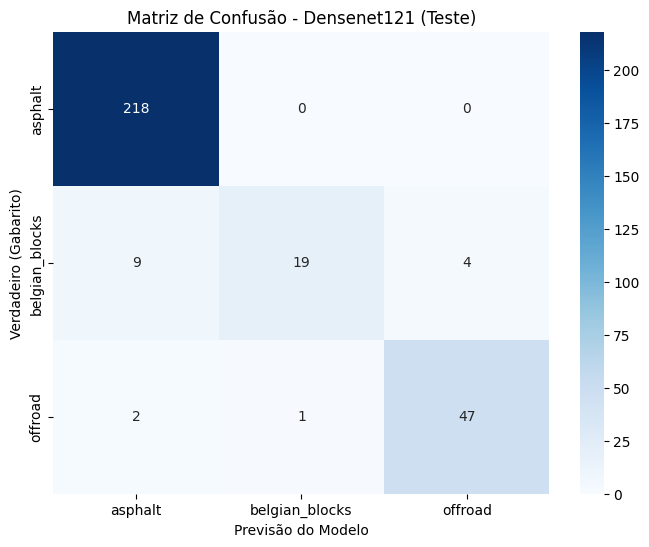


Relatório de Classificação Final:
                precision    recall  f1-score   support

       asphalt       0.95      1.00      0.98       218
belgian_blocks       0.95      0.59      0.73        32
       offroad       0.92      0.94      0.93        50

      accuracy                           0.95       300
     macro avg       0.94      0.84      0.88       300
  weighted avg       0.95      0.95      0.94       300



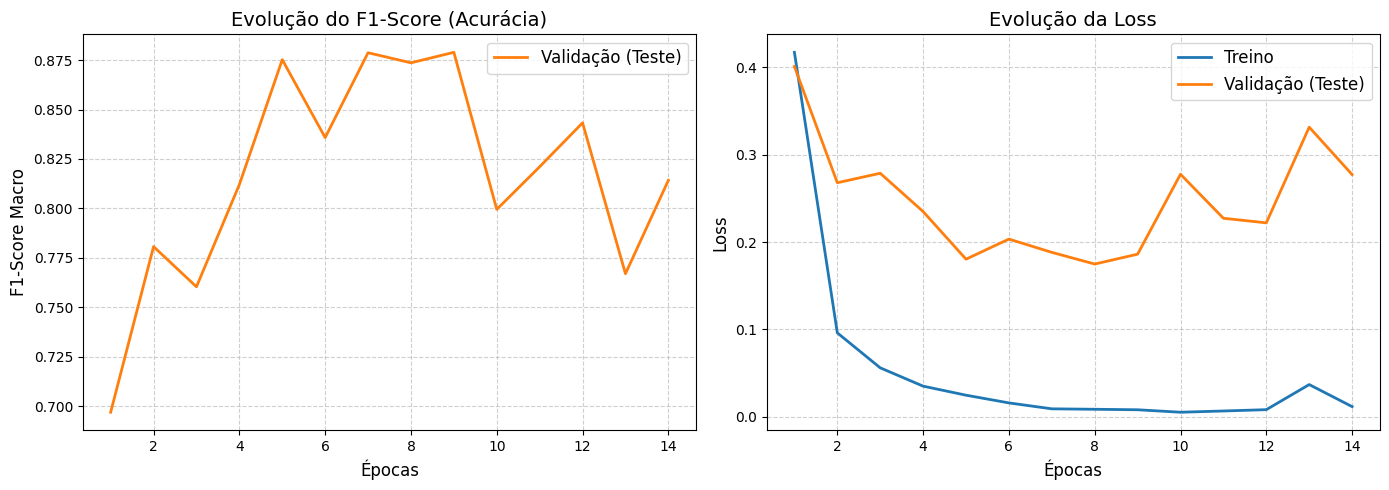

In [ ]:


print("Carregando os pesos do melhor modelo")
model_dense.load_state_dict(torch.load('melhor_densenet121.pth'))
model_dense.eval()

all_preds = []
all_labels = []

# Passa o dataset de teste inteiro pela rede uma última vez
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_dense(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Pega os nomes das classes na ordem correta
class_names = test_dataset.classes


# Matriz de Confusão

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Densenet121 (Teste)')
plt.ylabel('Verdadeiro (Gabarito)')
plt.xlabel('Previsão do Modelo')
plt.show()

# Relatório de Métricas Detalhado
print("\nRelatório de Classificação Final:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Pega o número de épocas que realmente rodaram
epochs = range(1, len(history_dense['train_loss']) + 1)

# Cria a figura com 2 gráficos lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Acurácia / F1-Score
# vamos plotar apenas a evolução da Validação/Teste.
ax1.plot(epochs, history_dense['test_f1'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax1.set_title('Evolução do F1-Score (Acurácia)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('F1-Score Macro', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# Gráfico 2: Loss (Função de Custo)
# Aqui plotamos Treino vs Validação para ver se há Overfitting
ax2.plot(epochs, history_dense['train_loss'], label='Treino', color='#1f77b4', linewidth=2)
ax2.plot(epochs, history_dense['test_loss'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax2.set_title('Evolução da Loss', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

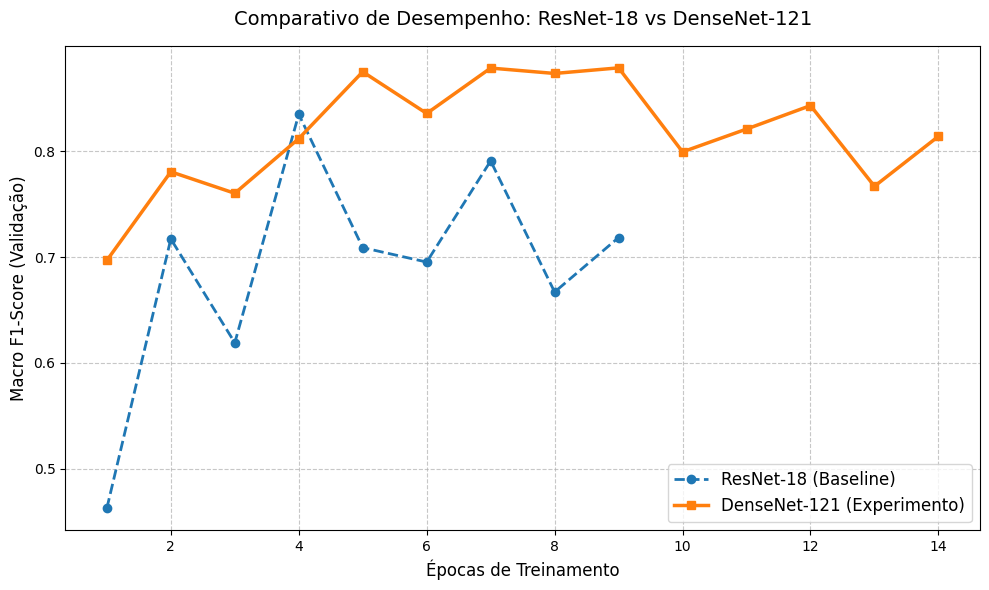

In [ ]:
# Calcula as épocas reais que cada modelo rodou
epocas_resnet = range(1, len(history['test_f1']) + 1)
epocas_densenet = range(1, len(history_dense['test_f1']) + 1)

plt.figure(figsize=(10, 6))

# Plot da ResNet-18 (Linha tracejada azul)
plt.plot(epocas_resnet, history['test_f1'], label='ResNet-18 (Baseline)',
         marker='o', linestyle='dashed', color='#1f77b4', linewidth=2)

# Plot da DenseNet-121 (Linha contínua laranja)
plt.plot(epocas_densenet, history_dense['test_f1'], label='DenseNet-121 (Experimento)',
         marker='s', color='#ff7f0e', linewidth=2.5)

plt.title('Comparativo de Desempenho: ResNet-18 vs DenseNet-121', fontsize=14, pad=15)
plt.xlabel('Épocas de Treinamento', fontsize=12)
plt.ylabel('Macro F1-Score (Validação)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()



*   **Asphalt:** A rede atingiu a perfeição no recall (1.00) e um F1-Score de 0.98. De todas as 218 vias pavimentadas reais presentes no teste, a DenseNet conseguiu encontrar absolutamente todas, zerando os falsos negativos para esta classe.
*   **Belgian_blocks:** O F1-Score teve um ganho marginal, fechando em 0.73. A análise das métricas revelou um comportamento específico: a rede obteve uma precisão altíssima (0.95), mas um recall baixo (0.59). Isso significa que a DenseNet é extremamente conservadora; ela raramente dá um "alarme falso" chamando asfalto de bloco belga, mas acaba "deixando passar" quase metade dos blocos verdadeiros, confundindo-os com outras classes.


*   **Offroad:** O ganho arquitetural brilhou na identificação de estradas de terra. O F1-Score saltou de 0.85 (ResNet) para 0.93 (DenseNet). O modelo errou apenas 3 das 50 imagens de teste, provando que a extração de características mais profunda lidou perfeitamente com a variação visual de poças e lama.

##Imagens que a Densenet errou

Total de imagens erradas no Teste: 16



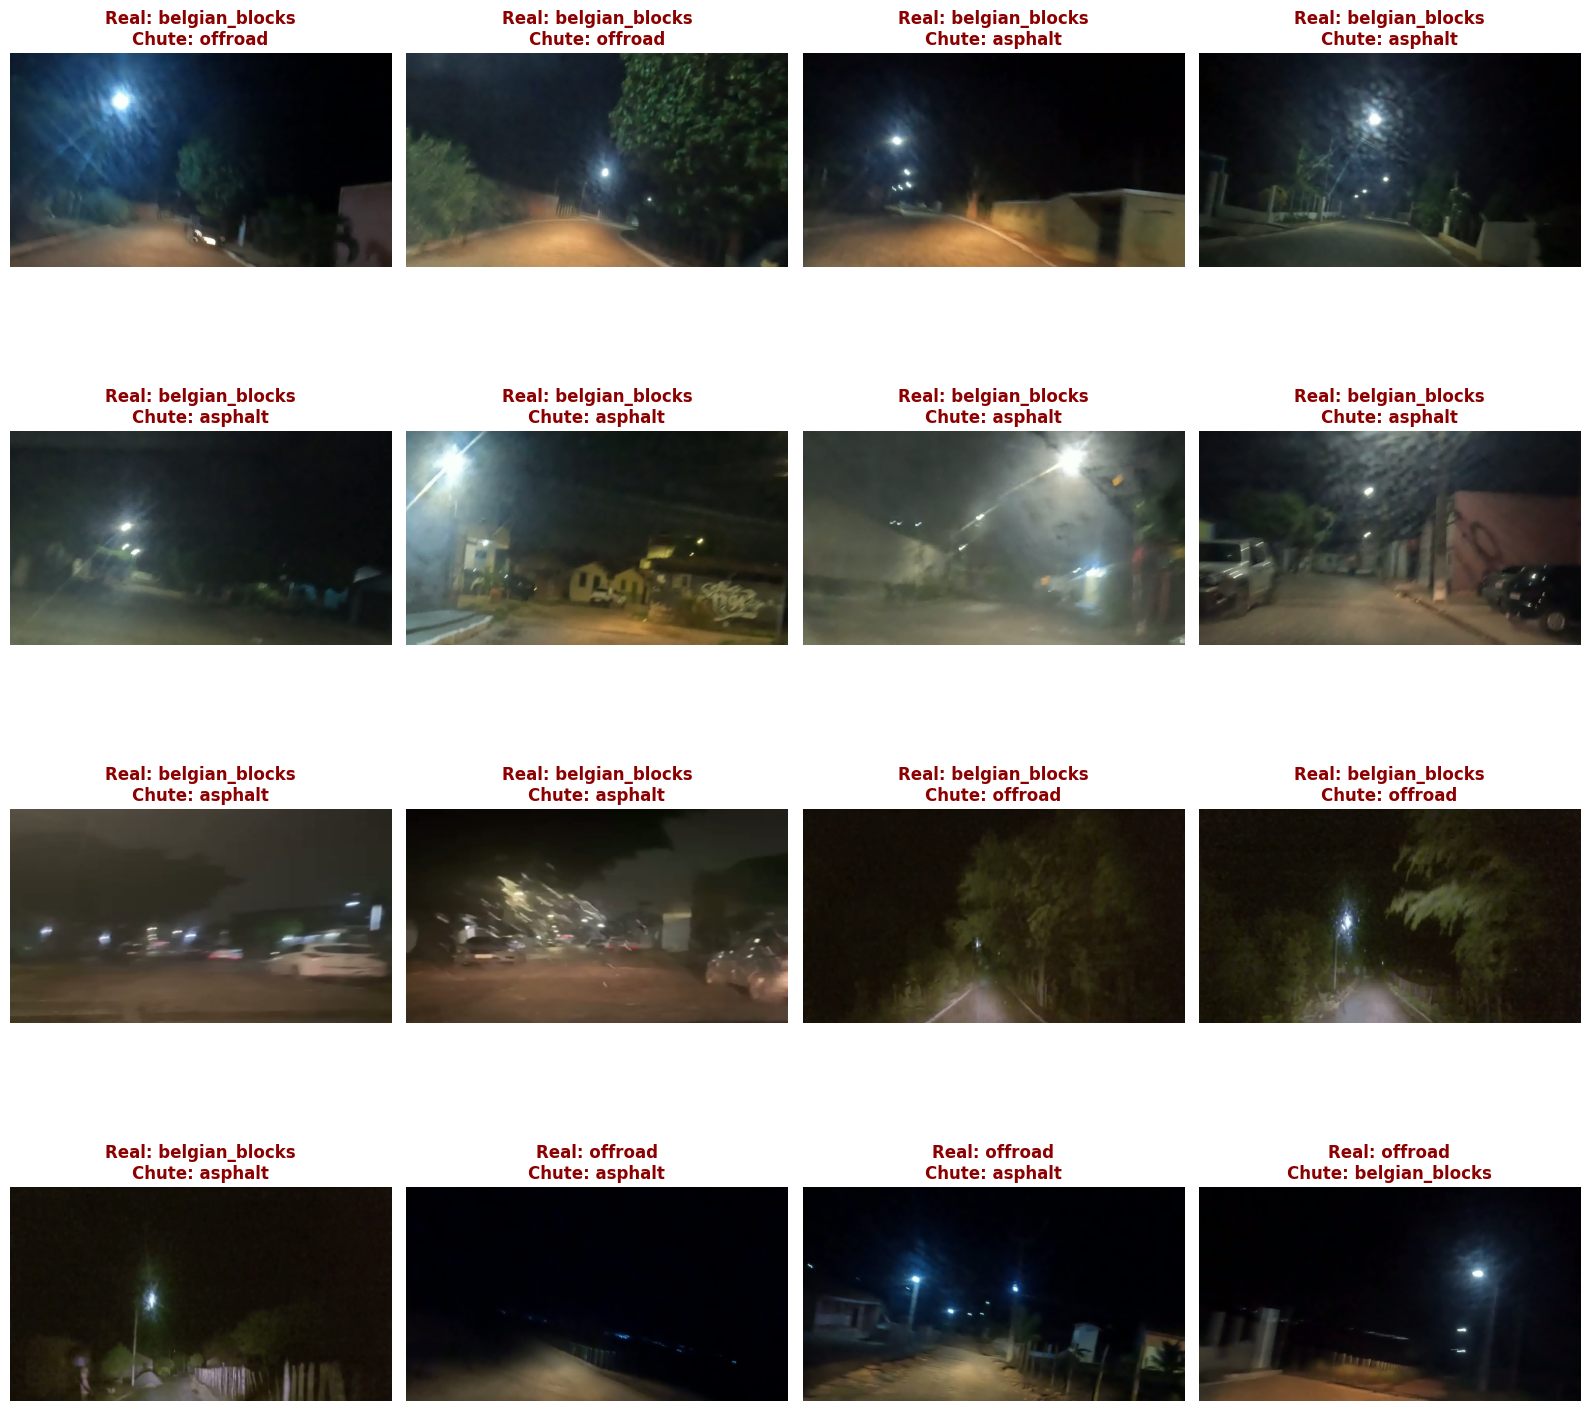

In [ ]:
# Encontra as posições (índices) exatas onde o modelo errou
erros_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]

print(f"Total de imagens erradas no Teste: {len(erros_indices)}\n")

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten() # Achata a matriz de gráficos para facilitar o loop

for i, ax in enumerate(axes):
    if i < len(erros_indices):
        # Pega o índice do erro atual
        idx = erros_indices[i]

        # Pega o caminho do arquivo original direto do ImageFolder
        caminho_imagem = test_dataset.samples[idx][0]
        imagem = Image.open(caminho_imagem) # Abre a foto original (sem normalização)

        # Pega os nomes das classes para o título
        classe_real = class_names[all_labels[idx]]
        classe_prevista = class_names[all_preds[idx]]

        ax.imshow(imagem)
        ax.set_title(f"Real: {classe_real}\nChute: {classe_prevista}",
                     color="darkred", fontsize=12, fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

##Conclusão sobre a DenseNet

A substituição da arquitetura base pela DenseNet-121 resultou em um salto significativo de desempenho. O modelo atingiu seu ápice de generalização na Época 9, registrando um Macro F1-Score de 0.88 (superando os 0.84 do baseline) e uma notável acurácia global de 94.6% no conjunto de teste. A premissa de que as conexões densas (dense blocks) que reaproveitam mapas de características das camadas anteriores ajudariam na diferenciação fina das texturas foi confirmada pelos dados. Entretando a dificuldade nos Belgian_blocks continua.

#Investigação experimental 2

A conclusão do experimento 1 revelou um limite claro na nossa abordagem atual: a rede atingiu excelente precisão geral, mas o recall da classe minoritária Belgian Blocks permaneceu estagnado. O fato de uma arquitetura com extração de características muito mais densa e profunda não ter resolvido esse erro indica que atingimos um gargalo representativo nos dados.

Portanto, o Experimento 2 abandona a busca por modelos mais complexos (Model-Centric AI) e adota uma abordagem focada no enriquecimento dos dados (Data-Centric AI). A hipótese central é que, ao aplicar técnicas mais agressivas e direcionadas de Data Augmentation, podemos forçar a rede a aprender a "textura" intrínseca dos materiais, em vez de decorar a macroestrutura das fotos.

A Técnica Escolhida: Random Resized Crop Estratégico
Para este experimento, adicionamos a transformação transforms.RandomResizedCrop(224, scale=(0.6, 1.0)) ao pipeline de treinamento. Esta escolha técnica baseia-se em uma justificativa: Recortar pedaços aleatórios da imagem e redimensioná-los força a rede a classificar a via baseada puramente na textura do chão (os paralelepípedos, a terra, as rachaduras do asfalto), impedindo que o modelo use "atalhos" visuais, como o formato do horizonte, árvores marginais ou o capô do carro que gravou o vídeo.

##Treino DenseNet com RandomResizedCrop

In [ ]:
print("Recriando DataLoaders com RandomResizedCrop...")

train_transforms_crop = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), # scale=(0.6, 1.0) impede que o recorte seja apenas o céu.
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data_crop = ImageFolder(root=dataset_train, transform=train_transforms_crop)
train_loader_crop = DataLoader(train_data_crop, batch_size=32, shuffle=True)

torch.cuda.empty_cache()
gc.collect()

weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

model_dense_crop = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model_dense_crop.classifier = nn.Linear(model_dense_crop.classifier.in_features, 3)
model_dense_crop = model_dense_crop.to(device)

optimizer_crop = torch.optim.Adam(model_dense_crop.parameters(), lr=0.0001)

num_epochs = 20
patience = 5
epochs_no_improve = 0
best_f1_crop = 0.0

# Novo dicionário para não apagar o histórico antigo
history_crop = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'test_f1': []}

# LOOP DE TREINAMENTO (COM O NOVO LOADER)
print("\nIniciando o treinamento da DenseNet (Experimento: Resized Crop)...")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 20)

    model_dense_crop.train()
    running_train_loss = 0.0
    running_train_corrects = 0

    # Usando o train_loader_crop aqui!
    train_bar = tqdm(train_loader_crop, desc="Treinando")

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_crop.zero_grad()
        outputs = model_dense_crop(inputs)
        loss = criterion(outputs, labels) # Usando a mesma loss com pesos (Class Weights)

        loss.backward()
        optimizer_crop.step()

        _, preds = torch.max(outputs, 1)
        running_train_loss += loss.item() * inputs.size(0)
        running_train_corrects += torch.sum(preds == labels.data).item()

        train_bar.set_postfix(loss=loss.item())

    epoch_train_loss = running_train_loss / len(train_loader_crop.dataset)
    epoch_train_acc = running_train_corrects / len(train_loader_crop.dataset)

    history_crop['train_loss'].append(epoch_train_loss)
    history_crop['train_acc'].append(epoch_train_acc)

    # --- TESTE ---
    model_dense_crop.eval()
    running_test_loss = 0.0
    running_test_corrects = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        #  O test_loader continua o original, pois não alteramos os dados de validação
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_dense_crop(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            running_test_corrects += torch.sum(preds == labels.data).item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    epoch_test_acc = running_test_corrects / len(test_loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')

    history_crop['test_loss'].append(epoch_test_loss)
    history_crop['test_acc'].append(epoch_test_acc)
    history_crop['test_f1'].append(epoch_f1)

    print(f"loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_test_loss:.4f} - val_accuracy: {epoch_test_acc:.4f} - (val_macro_f1: {epoch_f1:.4f})")

    # --- EARLY STOPPING ---
    if epoch_f1 > best_f1_crop:
        print(f"Novo recorde de F1-Score ({epoch_f1:.4f})! Salvando os pesos do modelo...")
        best_f1_crop = epoch_f1
        # Salvando com um nome novo
        torch.save(model_dense_crop.state_dict(), 'melhor_densenet_crop.pth')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Sem melhora no F1-Score. Paciência: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"\n[Early Stopping] Treinamento abortado para evitar overfitting!")
            break

print("\nTreinamento do Experimento com Crop concluído!")

Recriando DataLoaders com RandomResizedCrop...

Iniciando o treinamento da DenseNet (Experimento: Resized Crop)...

Epoch 1/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.18it/s, loss=0.13]


loss: 0.4626 - accuracy: 0.7689 - val_loss: 0.4107 - val_accuracy: 0.8467 - (val_macro_f1: 0.6711)
Novo recorde de F1-Score (0.6711)! Salvando os pesos do modelo...

Epoch 2/20
--------------------


Treinando: 100%|██████████| 29/29 [00:23<00:00,  1.22it/s, loss=0.986]


loss: 0.1229 - accuracy: 0.9733 - val_loss: 0.2512 - val_accuracy: 0.9100 - (val_macro_f1: 0.8232)
Novo recorde de F1-Score (0.8232)! Salvando os pesos do modelo...

Epoch 3/20
--------------------


...

loss: 0.0088 - accuracy: 0.9989 - val_loss: 0.2092 - val_accuracy: 0.9300 - (val_macro_f1: 0.8379)
Sem melhora no F1-Score. Paciência: 3/5

Epoch 11/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.18it/s, loss=0.00383]


loss: 0.0095 - accuracy: 0.9989 - val_loss: 0.2723 - val_accuracy: 0.9267 - (val_macro_f1: 0.8119)
Sem melhora no F1-Score. Paciência: 4/5

Epoch 12/20
--------------------


Treinando: 100%|██████████| 29/29 [00:24<00:00,  1.18it/s, loss=0.23]


loss: 0.0138 - accuracy: 0.9956 - val_loss: 0.2934 - val_accuracy: 0.9200 - (val_macro_f1: 0.8097)
Sem melhora no F1-Score. Paciência: 5/5

[Early Stopping] Treinamento abortado para evitar overfitting!

Treinamento do Experimento com Crop concluído!


##Análise da Densenet com RandomResizedCrop

Carregando os pesos do melhor modelo


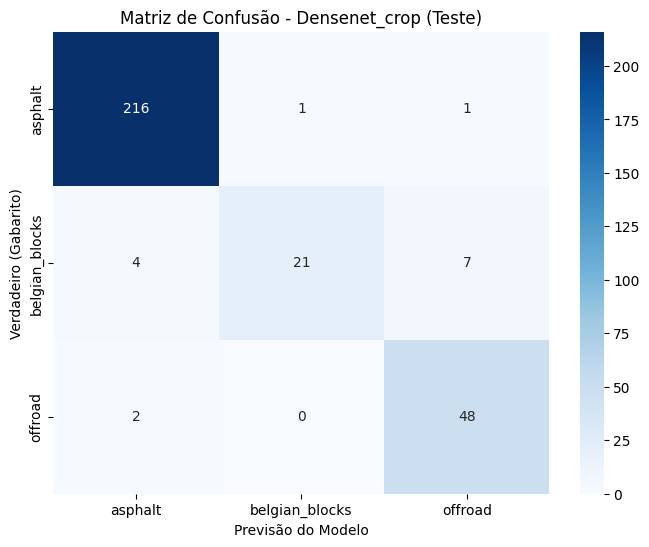


Relatório de Classificação Final:
                precision    recall  f1-score   support

       asphalt       0.97      0.99      0.98       218
belgian_blocks       0.95      0.66      0.78        32
       offroad       0.86      0.96      0.91        50

      accuracy                           0.95       300
     macro avg       0.93      0.87      0.89       300
  weighted avg       0.95      0.95      0.95       300



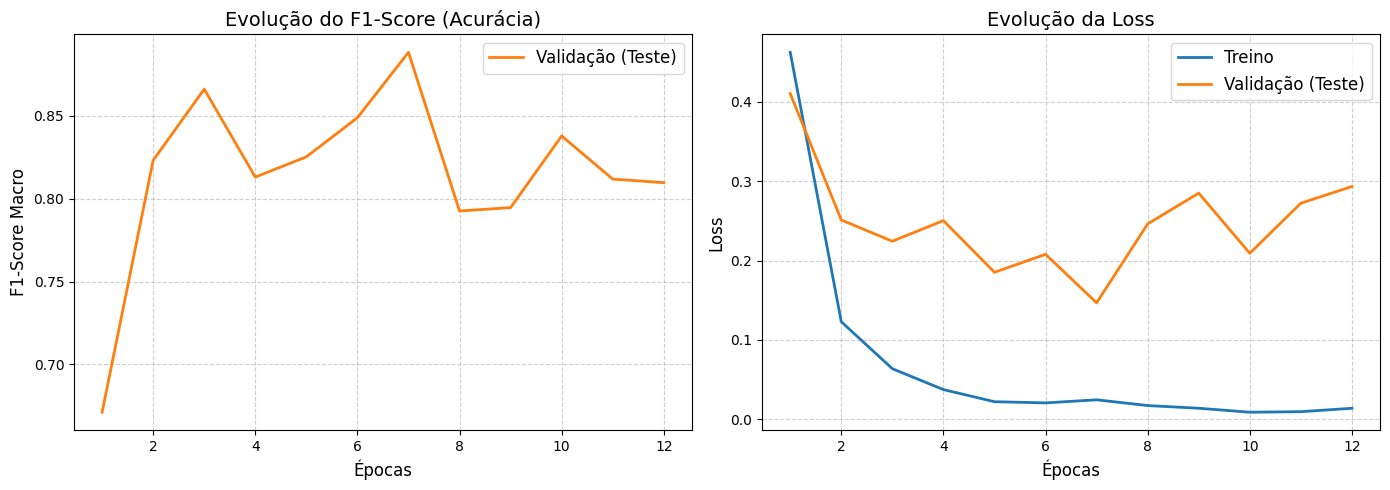

In [ ]:


print("Carregando os pesos do melhor modelo")
model_dense_crop.load_state_dict(torch.load('melhor_densenet_crop.pth'))
model_dense_crop.eval()

all_preds = []
all_labels = []

# Passa o dataset de teste inteiro pela rede uma última vez
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_dense_crop(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Pega os nomes das classes na ordem correta
class_names = test_dataset.classes


# Matriz de Confusão

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Densenet_crop (Teste)')
plt.ylabel('Verdadeiro (Gabarito)')
plt.xlabel('Previsão do Modelo')
plt.show()

# Relatório de Métricas Detalhado
print("\nRelatório de Classificação Final:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Pega o número de épocas que realmente rodaram
epochs = range(1, len(history_crop['train_loss']) + 1)

# Cria a figura com 2 gráficos lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Acurácia / F1-Score
# vamos plotar apenas a evolução da Validação/Teste.
ax1.plot(epochs, history_crop['test_f1'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax1.set_title('Evolução do F1-Score (Acurácia)', fontsize=14)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('F1-Score Macro', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=12)

# Gráfico 2: Loss (Função de Custo)
# Aqui plotamos Treino vs Validação para ver se há Overfitting
ax2.plot(epochs, history_crop['train_loss'], label='Treino', color='#1f77b4', linewidth=2)
ax2.plot(epochs, history_crop['test_loss'], label='Validação (Teste)', color='#ff7f0e', linewidth=2)
ax2.set_title('Evolução da Loss', fontsize=14)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()



*   **Asphalt:** A rede manteve sua robustez quase perfeita na classe majoritária, com F1-Score de 0.98 e recall de 0.99. O recorte não prejudicou o entendimento do que é uma via pavimentada.
*   **Belgian_blocks:** O sucesso da abordagem Data-Centric é inegável aqui. Forçar a rede a analisar recortes locais da imagem fez o recall da classe minoritária saltar de 0.59 (no Exp 1) para 0.66. Consequentemente, o F1-Score dos blocos belgas atingiu seu recorde absoluto de 0.78 (contra 0.71 do Baseline e 0.73 do Exp 1). A rede finalmente parou de olhar para o horizonte e aprendeu a identificar a textura geométrica das pedras.


*   **Offroad:** O foco em texturas locais gerou um leve trade-off. O F1-Score do off-road caiu sutilmente de 0.93 (Exp 1) para 0.91. A precisão de 0.86 revela que a rede deu alguns alarmes falsos (confundiu 7 blocos belgas com off-road). Visualmente, isso faz todo sentido empírico: um "recorte com zoom" muito focado em um bloco belga sujo de lama perde o contexto geométrico e se assemelha quase perfeitamente a uma estrada de terra.


##Conclusão da Densenet com RandomResizedCrop

A aplicação do RandomResizedCrop validou brilhantemente a hipótese de que o gargalo da solução residia na representatividade dos dados. O Experimento 2 produziu o melhor modelo geral do desafio, alcançando um Macro F1-Score de 0.89 e uma acurácia global de 95% na Época 7.

#Conclusão geral do Desafio:
Com base nos experimentos realizados (Baseline com ResNet-18 e abordagens investigativas), a análise crítica do modelo final (Experimento 2) revela os seguintes pontos:

**Onde o modelo parece funcionar bem:**
O modelo apresenta um desempenho de excelência na identificação de vias do tipo Asphalt e Off-road. A estratégia de utilizar arquiteturas pré-treinadas (Transfer Learning) em conjunto com a técnica de pesos matemáticos na função de custo (Class Weights) funcionou muito bem como eu imaginava. Essa combinação evitou que o modelo ficasse "viciado" em chutar apenas a classe majoritária.

**Onde parace falhar:**
A principal dificuldade de classificação reside na classe minoritária Belgian Blocks. Apesar da abordagem Data-Centric (recortes locais usando RandomResizedCrop) ter melhorado muito o reconhecimento dessa textura, o modelo ainda apresenta alguns vazamentos. Ele tende a falhar em situações de limite visual: confunde blocos belgas cobertos de poças ou sujeira extrema com vias Off-road, e confunde blocos muito lisos, rachados ou mal iluminados com Asphalt.

**Que limitação você enxerga na sua solução:**
A limitação fundamental desta solução não é algorítmica ou arquitetural, mas sim representativa (limite de dados). O dataset fornecido possui um desbalanceamento extremo, contando com apenas 94 imagens de treino para a classe Belgian Blocks (contra 655 de asfalto). Redes neurais profundas precisam de variabilidade visual para generalizar. Com um número tão reduzido de amostras, acredito que o limite do que a rede consegue extrair de características matemáticas das pedras foi alcançado.

Se eu tivesse mais tempo, com certeza concetraria minhas energias em enriquecer o Dataset e estudos de como melhorar a qualidade.

Utilizei o Gemini para resolução de bugs, dúvidas sobre as arquitetura das redes e para deixar minhas falas mais claras e objetivas.